# Chapter 09: Neyman-Scott, Estimating Functions, and Semiparametric Geometry

Source orientation: printed pages 191-213; PDF pages 197-219.

This notebook rebuilds the chapter as a computational lesson about inference when the parameter we care about is tangled with many nuisance directions. The visual thread is geometric: nuisance fibers, estimating-function orthogonality, semiparametric projection, and spike intervals that reveal what can go wrong when nuisance dimension grows with the sample.

The notebook is standalone. It uses original prose and executable experiments rather than relying on the book text being open beside it.

## Translation Guide

The chapter's statistical ideas become the following computational objects.

| Statistical phrase | Computational translation | Geometric picture |
| --- | --- | --- |
| Parameter of interest | a low-dimensional coordinate such as a common variance or regression slope | a horizontal coordinate on the model manifold |
| Nuisance parameter | many coordinates needed to describe the model but not the final target | fibers over the target coordinate |
| Neyman-Scott problem | one nuisance mean per group while group size stays small | fibers multiply as data accumulate |
| Estimating function | a statistic whose expectation vanishes at the target value | a covector tested against sample fluctuations |
| Efficient score | the score after subtracting nuisance tangent components | orthogonal projection away from the nuisance tangent space |
| Semiparametric model | finite target plus infinite or very large nuisance component | a finite direction inside a broad function space |
| Spike interval | a short interval containing a local burst of observations | a visual diagnostic for incidental local structure |

The route is: first see why a naive likelihood can point in the wrong direction, then rebuild the inference target using unbiased estimating equations and projection geometry.

In [ ]:
from __future__ import annotations

import json
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import plotly.graph_objects as go

from IPython.display import HTML, Image, display

# Discover the course root from the notebook location or current working directory.
def find_book_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for candidate in [start, *start.parents]:
        if (candidate / 'AGENTS.md').exists() and (candidate / 'Information Geometry and Its Applications.pdf').exists():
            return candidate
        nested = candidate / 'Information-Geometry-and-Its-Applications'
        if (nested / 'AGENTS.md').exists():
            return nested
    raise RuntimeError('Could not locate Information-Geometry-and-Its-Applications root')

BOOK_ROOT = find_book_root()
ARTIFACT_DIR = BOOK_ROOT / 'artifacts' / 'chapter-09'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(20260501)
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 180,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

artifact_log: dict[str, dict[str, object]] = {}

def savefig(name: str, fig):
    path = ARTIFACT_DIR / name
    fig.savefig(path, bbox_inches='tight')
    artifact_log[name] = {'path': str(path.relative_to(BOOK_ROOT)), 'bytes': path.stat().st_size}
    display(Image(filename=str(path)))
    plt.close(fig)
    return path

def save_html(name: str, fig):
    path = ARTIFACT_DIR / name
    fig.write_html(path, include_plotlyjs=True, full_html=True)
    artifact_log[name] = {'path': str(path.relative_to(BOOK_ROOT)), 'bytes': path.stat().st_size}
    display(HTML(f'<a href="{path.as_posix()}">Open {name}</a>'))
    return path

print('BOOK_ROOT =', BOOK_ROOT)
print('ARTIFACT_DIR =', ARTIFACT_DIR.relative_to(BOOK_ROOT))

## 1. Nuisance Fibers

Imagine a model written as $(\psi, \lambda)$, where $\psi$ is the target and $\lambda$ is everything else. Fixing $\psi$ leaves a fiber of nuisance values. Ordinary large-sample likelihood theory is comfortable when the number of nuisance coordinates stays fixed while observations grow. The Neyman-Scott setting breaks that comfort: every new group brings a new nuisance mean, so the fiber dimension grows with the sample.

The picture below is deliberately low-dimensional. The horizontal axis is the target coordinate, while each colored curve is a nuisance fiber. More data should sharpen the target; instead, if every new group contributes a fresh nuisance direction with only a few observations, the fiber bundle keeps receiving new strands.

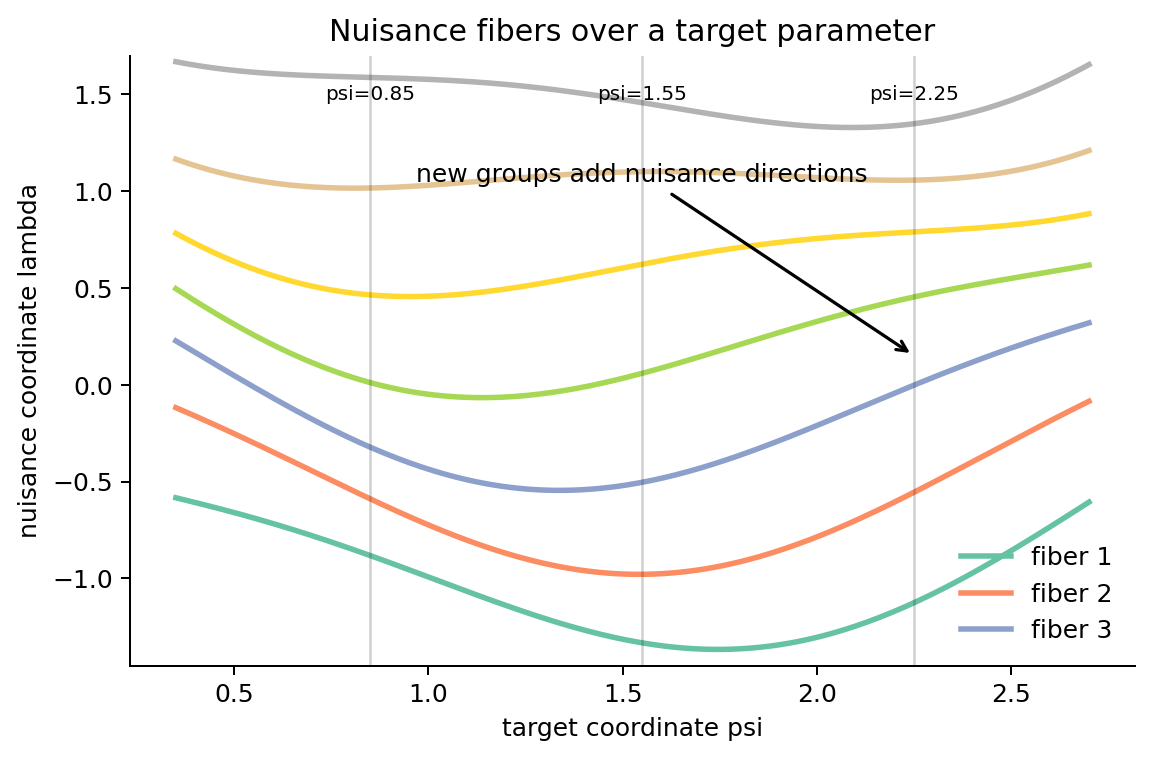

WindowsPath('Information-Geometry-and-Its-Applications/artifacts/chapter-09/nuisance_fibers.png')

In [2]:
psi = np.linspace(0.35, 2.7, 220)
fig, ax = plt.subplots(figsize=(7.2, 4.4))
colors = plt.cm.Set2(np.linspace(0, 1, 7))
for k, c in enumerate(colors):
    offset = -1.2 + 0.42 * k
    waviness = 0.20 * np.sin(2.5 * psi + 0.8 * k)
    ax.plot(psi, offset + 0.35 * (psi - 1.5) ** 2 + waviness, color=c, lw=2.2, label=f'fiber {k+1}' if k < 3 else None)

for x in [0.85, 1.55, 2.25]:
    ax.axvline(x, color='0.15', lw=1, alpha=0.22)
    ax.text(x, 1.55, f'psi={x:.2f}', ha='center', va='top', fontsize=8)

ax.annotate('new groups add nuisance directions', xy=(2.25, 0.15), xytext=(1.55, 1.05),
            arrowprops={'arrowstyle': '->', 'lw': 1.3}, ha='center')
ax.set_xlabel('target coordinate psi')
ax.set_ylabel('nuisance coordinate lambda')
ax.set_title('Nuisance fibers over a target parameter')
ax.set_ylim(-1.45, 1.7)
ax.legend(frameon=False, loc='lower right')
savefig('nuisance_fibers.png', fig)

## 2. The Neyman-Scott Experiment

A compact version of the Neyman-Scott model is

$$Y_{ij}=\theta_i+\varepsilon_{ij}, \qquad \varepsilon_{ij}\sim N(0,\sigma^2), \qquad i=1,\ldots,n,\ j=1,\ldots,m.$$

The target is the common variance $\sigma^2$. The nuisance parameters are the group means $\theta_i$. If $m$ is fixed, each $\theta_i$ is estimated from only $m$ observations no matter how large $n$ becomes.

The likelihood estimator of $\sigma^2$ after plugging in group sample means is

$$\hat\sigma^2_{\text{profile}} = \frac{1}{nm}\sum_{i=1}^n\sum_{j=1}^m (Y_{ij}-\bar Y_i)^2.$$

For fixed $m$, its expectation is $((m-1)/m)\sigma^2$. That is not a small-sample wrinkle; when $m=2$, it converges to half the truth. The unbiased within-group estimating-function version divides by $n(m-1)$ instead. Same residuals, different geometry: the estimating function accounts for the nuisance direction consumed by each group mean.

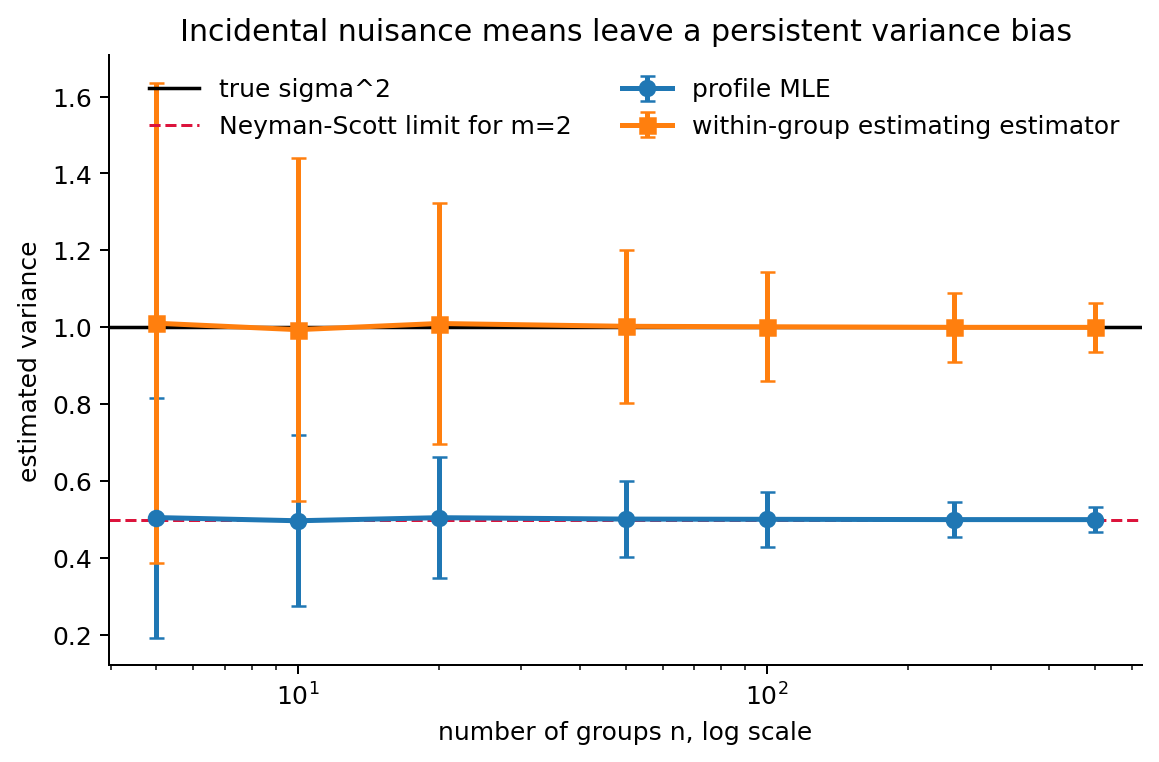

{'m': 2,
 'true_sigma2': 1.0,
 'profile_last_mean': 0.49991945479297917,
 'estimating_last_mean': 0.9998389095859583,
 'theory_profile_limit': 0.5}

In [3]:
def simulate_neyman_scott(n_groups: int, m: int, sigma: float = 1.0, reps: int = 2000):
    theta = rng.normal(0, 1.4, size=(reps, n_groups, 1))
    y = theta + rng.normal(0, sigma, size=(reps, n_groups, m))
    ybar = y.mean(axis=2, keepdims=True)
    ss = ((y - ybar) ** 2).sum(axis=(1, 2))
    profile = ss / (n_groups * m)
    estimating = ss / (n_groups * (m - 1))
    return profile, estimating

n_grid = np.array([5, 10, 20, 50, 100, 250, 500])
summary = []
for n in n_grid:
    prof, est = simulate_neyman_scott(int(n), m=2, reps=2500)
    summary.append((n, prof.mean(), prof.std(), est.mean(), est.std()))
summary = np.array(summary)

fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.errorbar(summary[:,0], summary[:,1], yerr=summary[:,2], marker='o', capsize=3, lw=2, label='profile MLE')
ax.errorbar(summary[:,0], summary[:,3], yerr=summary[:,4], marker='s', capsize=3, lw=2, label='within-group estimating estimator')
ax.axhline(1.0, color='black', lw=1.4, label='true sigma^2')
ax.axhline(0.5, color='crimson', lw=1.2, ls='--', label='Neyman-Scott limit for m=2')
ax.set_xscale('log')
ax.set_xlabel('number of groups n, log scale')
ax.set_ylabel('estimated variance')
ax.set_title('Incidental nuisance means leave a persistent variance bias')
ax.legend(frameon=False, ncols=2)
savefig('neyman_scott_bias.png', fig)

neyman_scott_summary = {
    'm': 2,
    'true_sigma2': 1.0,
    'profile_last_mean': float(summary[-1,1]),
    'estimating_last_mean': float(summary[-1,3]),
    'theory_profile_limit': 0.5,
}
neyman_scott_summary

## 3. Estimating-Function Geometry

An estimating function $G(Y,\psi)$ is useful when $E_{\psi,\lambda}[G(Y,\psi)]=0$ at the target value. In a score-based picture, the full score has a target component and nuisance components. A naive target score may lean into nuisance directions. The efficient version removes the nuisance projection, leaving a horizontal direction.

For the Neyman-Scott variance, the residual sum of squares after subtracting group means is perpendicular to shifts of the group means: changing a group mean moves every observation in the group together, while centered residuals sum to zero. The figure below represents that idea as vectors in a tangent space. The efficient arrow is the part of the target score left after the nuisance component has been subtracted.

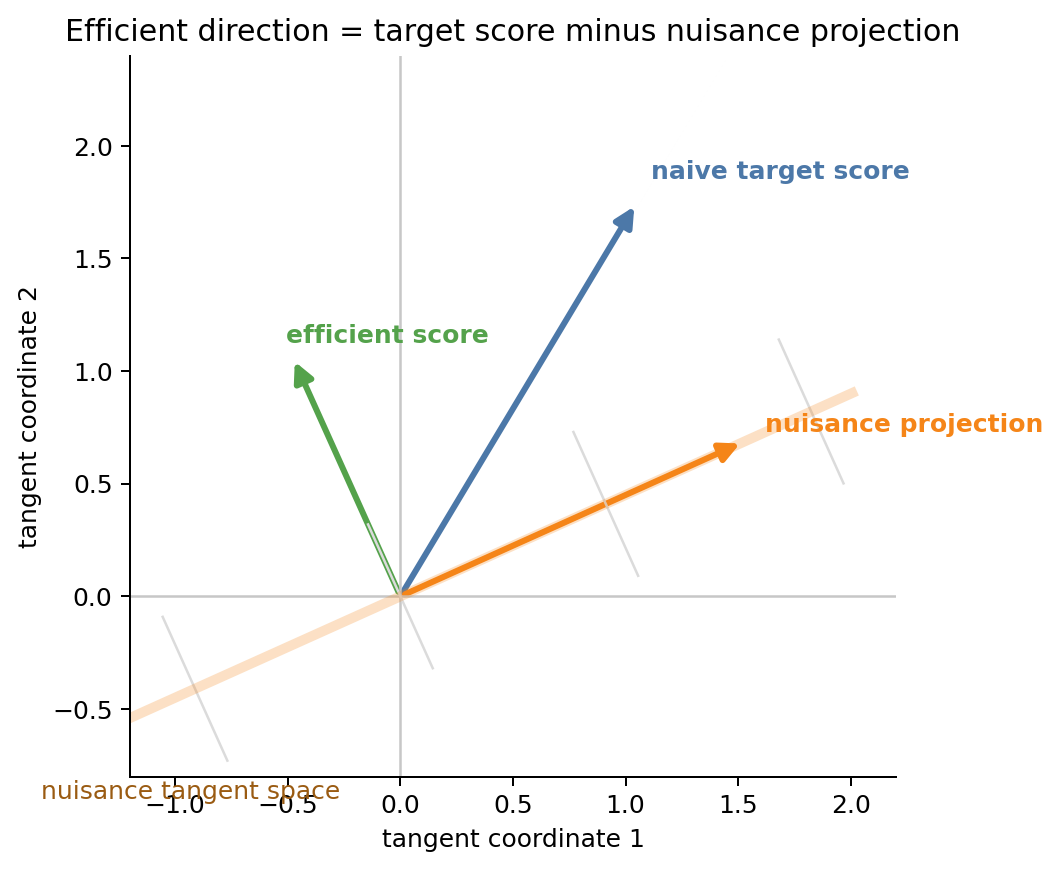

{'dot_efficient_with_nuisance': 5.551115123125783e-16,
 'target_norm2': 4.165,
 'decomposition_norm2': 4.164999999999997}

In [4]:
fig, ax = plt.subplots(figsize=(6.7, 5.2))
ax.axhline(0, color='0.78', lw=1)
ax.axvline(0, color='0.78', lw=1)

nuis = np.array([1.0, 0.45])
nuis = nuis / np.linalg.norm(nuis)
target = np.array([1.05, 1.75])
proj = nuis * np.dot(target, nuis)
efficient = target - proj

for scale in [-2, -1, 0, 1, 2]:
    base = scale * nuis
    perp = np.array([-nuis[1], nuis[0]])
    pts = np.vstack([base - 0.35 * perp, base + 0.35 * perp])
    ax.plot(pts[:,0], pts[:,1], color='0.86', lw=1)

vectors = [
    ('naive target score', target, '#4C78A8'),
    ('nuisance projection', proj, '#F58518'),
    ('efficient score', efficient, '#54A24B'),
]
for label, vec, color in vectors:
    ax.add_patch(FancyArrowPatch((0, 0), vec, arrowstyle='-|>', mutation_scale=16, lw=2.4, color=color))
    ax.text(vec[0] * 1.06, vec[1] * 1.06, label, color=color, weight='bold')

line = np.array([[-2.2, 2.2]])
ax.plot(line[0] * nuis[0], line[0] * nuis[1], color='#F58518', lw=4, alpha=0.25)
ax.text(-1.75*nuis[0], -1.75*nuis[1]-0.18, 'nuisance tangent space', color='#9A5B12')
ax.set_aspect('equal')
ax.set_xlim(-1.2, 2.2)
ax.set_ylim(-0.8, 2.4)
ax.set_xlabel('tangent coordinate 1')
ax.set_ylabel('tangent coordinate 2')
ax.set_title('Efficient direction = target score minus nuisance projection')
savefig('estimating_function_geometry.png', fig)

projection_check = {
    'dot_efficient_with_nuisance': float(np.dot(efficient, nuis)),
    'target_norm2': float(np.dot(target, target)),
    'decomposition_norm2': float(np.dot(proj, proj) + np.dot(efficient, efficient)),
}
projection_check

## 4. Semiparametric Projection

In a semiparametric model the nuisance object can be a whole function: a baseline density, a response curve, a censoring distribution, or a firing-rate background. The efficient score is still a projection problem. We work in an $L^2$-type inner product, project the target score onto the nuisance tangent space, and use the residual.

The interactive Plotly artifact below uses a finite Fourier basis as a small stand-in for an infinite nuisance space. The target score is a curve; the nuisance space is spanned by low-frequency directions. The efficient score is the residual curve after least-squares projection. Rotate conceptually from finite vectors to functions: the algebra is the same, only the space gets larger.

In [5]:
x = np.linspace(0, 1, 500)
target_score = 1.2*np.sin(2*np.pi*x) + 0.5*np.cos(4*np.pi*x) + 0.8*np.sin(6*np.pi*x) + 0.35*(x - 0.5)
basis = np.column_stack([
    np.ones_like(x),
    np.sin(2*np.pi*x),
    np.cos(2*np.pi*x),
    np.sin(4*np.pi*x),
    np.cos(4*np.pi*x),
])
coef, *_ = np.linalg.lstsq(basis, target_score, rcond=None)
nuisance_projection = basis @ coef
efficient_curve = target_score - nuisance_projection
inner_products = basis.T @ efficient_curve / len(x)

fig = go.Figure()
fig.add_trace(go.Scatter(x=x, y=target_score, mode='lines', name='target score', line={'width': 3}))
fig.add_trace(go.Scatter(x=x, y=nuisance_projection, mode='lines', name='nuisance projection', line={'width': 3}))
fig.add_trace(go.Scatter(x=x, y=efficient_curve, mode='lines', name='efficient residual', line={'width': 3}))
fig.update_layout(
    title='Semiparametric projection in a finite function basis',
    xaxis_title='sample coordinate u',
    yaxis_title='score value',
    template='plotly_white',
    width=850,
    height=480,
)
save_html('semiparametric_projection.html', fig)

semiparametric_check = {
    'max_abs_inner_product_with_basis': float(np.max(np.abs(inner_products))),
    'efficient_curve_energy': float(np.mean(efficient_curve**2)),
    'target_curve_energy': float(np.mean(target_score**2)),
}
semiparametric_check

{'max_abs_inner_product_with_basis': 1.8474284602110202e-16,
 'efficient_curve_energy': 0.29222170835251426,
 'target_curve_energy': 1.0103522602802013}

## 5. Spike Intervals as a Local Nuisance Diagnostic

The chapter's nuisance theme also appears in point-process language. Suppose observations are event times. A rate background is nuisance; a stimulus effect or low-dimensional modulation is the target. If we summarize only by local spike intervals, we can see where a nuisance baseline creates bursts that look like target signal.

The next figure simulates a simple inhomogeneous spike train. The top panel shows event times. The bottom panel shows inter-spike intervals. Short intervals cluster where the background rate rises. That visual is a warning: local bursts must be separated from the parameter of interest by an estimating rule or projection, not merely admired by the likelihood.

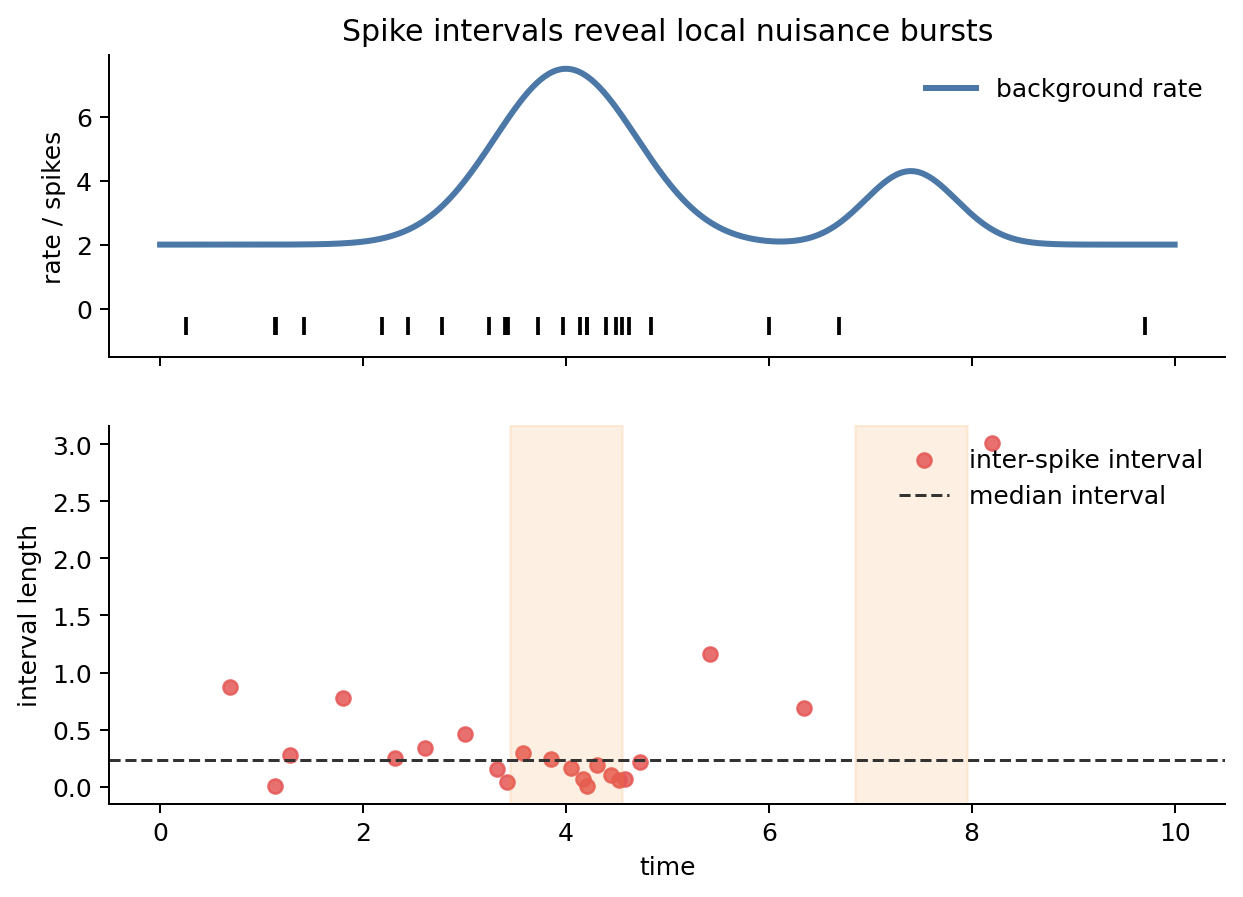

{'n_events': 23,
 'median_interval': 0.23050032256217357,
 'min_interval': 0.003254779049735035,
 'burst_fraction_shorter_than_half_median': 0.3181818181818182}

In [6]:
def simulate_inhomogeneous_poisson(rate_fn, t_end=10.0, max_rate=8.5, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    t = 0.0
    events = []
    while t < t_end:
        t += rng.exponential(1 / max_rate)
        if t >= t_end:
            break
        if rng.uniform() < rate_fn(t) / max_rate:
            events.append(t)
    return np.array(events)

rate_fn = lambda t: 2.0 + 5.5*np.exp(-0.5*((t-4.0)/0.7)**2) + 2.3*np.exp(-0.5*((t-7.4)/0.45)**2)
events = simulate_inhomogeneous_poisson(rate_fn, rng=rng)
intervals = np.diff(events)
midpoints = 0.5*(events[1:] + events[:-1])
t = np.linspace(0, 10, 500)

fig, axes = plt.subplots(2, 1, figsize=(8.0, 5.4), sharex=True, gridspec_kw={'height_ratios': [1, 1.25]})
axes[0].plot(t, [rate_fn(v) for v in t], color='#4C78A8', lw=2.4, label='background rate')
axes[0].eventplot(events, lineoffsets=-0.55, linelengths=0.55, color='black')
axes[0].set_ylabel('rate / spikes')
axes[0].set_title('Spike intervals reveal local nuisance bursts')
axes[0].legend(frameon=False, loc='upper right')

axes[1].scatter(midpoints, intervals, s=32, color='#E45756', alpha=0.85, label='inter-spike interval')
axes[1].axhline(np.median(intervals), color='0.2', lw=1.2, ls='--', label='median interval')
for center in [4.0, 7.4]:
    axes[1].axvspan(center-0.55, center+0.55, color='#F58518', alpha=0.12)
axes[1].set_xlabel('time')
axes[1].set_ylabel('interval length')
axes[1].legend(frameon=False, loc='upper right')
savefig('spike_intervals.png', fig)

spike_summary = {
    'n_events': int(len(events)),
    'median_interval': float(np.median(intervals)),
    'min_interval': float(np.min(intervals)),
    'burst_fraction_shorter_than_half_median': float(np.mean(intervals < 0.5*np.median(intervals))),
}
spike_summary

## 6. Applied Lab: Choose an Estimating Rule

The lab asks a practical question: if each subject, device, or site contributes only a tiny local sample, which variance estimator should be used for a common noise level?

We compare four estimators in repeated Neyman-Scott simulations:

1. profile likelihood with group means plugged in,
2. unbiased within-group estimating equation,
3. profile likelihood when group size is larger,
4. unbiased estimator when group size is larger.

The contrast separates two effects. Increasing the number of groups improves concentration, but it does not repair the profile-likelihood bias when group size is fixed. Increasing within-group replication reduces the incidental-parameter damage because each nuisance mean becomes better learned.

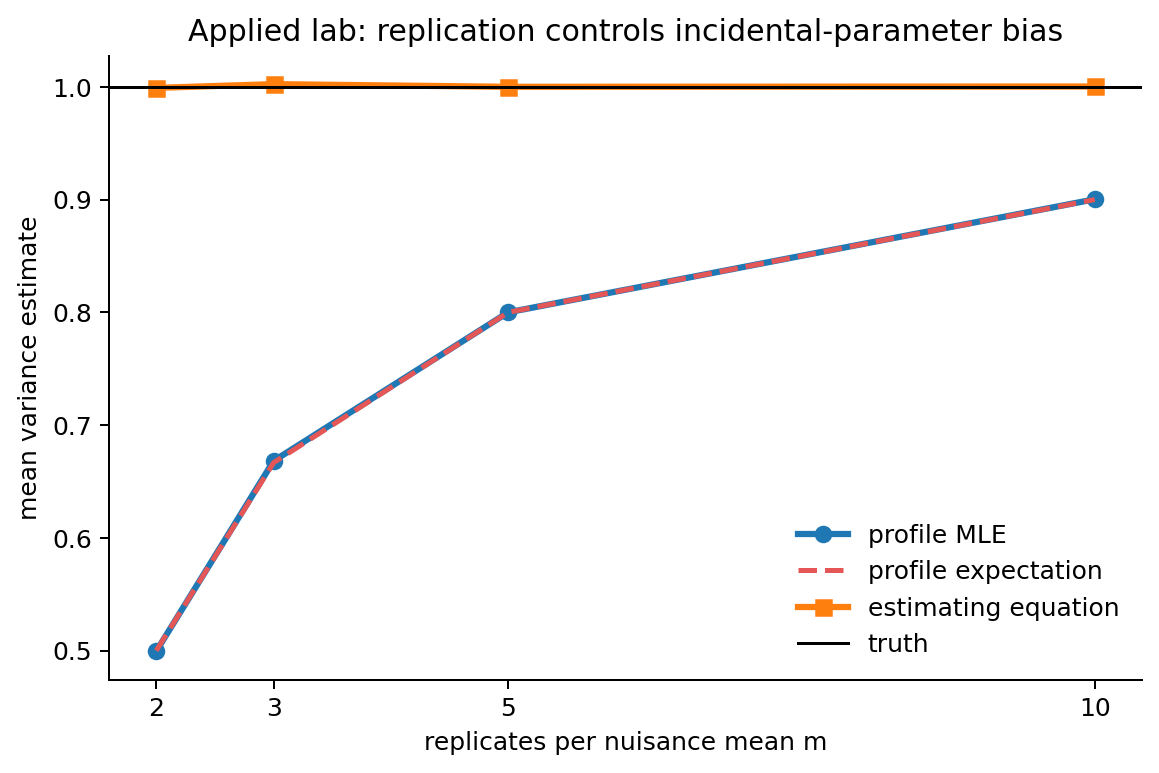

[{'m': 2,
  'profile_mean': 0.49952628420880874,
  'profile_sd': 0.040198185934070714,
  'estimating_mean': 0.9990525684176175,
  'estimating_sd': 0.08039637186814143,
  'profile_theory': 0.5},
 {'m': 3,
  'profile_mean': 0.6682444634474312,
  'profile_sd': 0.03960140269125654,
  'estimating_mean': 1.0023666951711467,
  'estimating_sd': 0.059402104036884805,
  'profile_theory': 0.6666666666666666},
 {'m': 5,
  'profile_mean': 0.8000073341048496,
  'profile_sd': 0.033432047587790725,
  'estimating_mean': 1.000009167631062,
  'estimating_sd': 0.04179005948473841,
  'profile_theory': 0.8},
 {'m': 10,
  'profile_mean': 0.9002605486086604,
  'profile_sd': 0.024241592266152686,
  'estimating_mean': 1.0002894984540671,
  'estimating_sd': 0.026935102517947427,
  'profile_theory': 0.9}]

In [7]:
m_values = [2, 3, 5, 10]
lab_rows = []
for m in m_values:
    prof, est = simulate_neyman_scott(300, m=m, reps=2000)
    lab_rows.append({
        'm': m,
        'profile_mean': float(prof.mean()),
        'profile_sd': float(prof.std()),
        'estimating_mean': float(est.mean()),
        'estimating_sd': float(est.std()),
        'profile_theory': (m-1)/m,
    })

fig, ax = plt.subplots(figsize=(7.4, 4.5))
ms = np.array([r['m'] for r in lab_rows])
profile_means = np.array([r['profile_mean'] for r in lab_rows])
est_means = np.array([r['estimating_mean'] for r in lab_rows])
ax.plot(ms, profile_means, marker='o', lw=2.5, label='profile MLE')
ax.plot(ms, [(m-1)/m for m in ms], color='#E45756', ls='--', lw=2, label='profile expectation')
ax.plot(ms, est_means, marker='s', lw=2.5, label='estimating equation')
ax.axhline(1.0, color='black', lw=1.2, label='truth')
ax.set_xlabel('replicates per nuisance mean m')
ax.set_ylabel('mean variance estimate')
ax.set_title('Applied lab: replication controls incidental-parameter bias')
ax.set_xticks(ms)
ax.legend(frameon=False)
savefig('applied_lab_variance_estimators.png', fig)

lab_rows

## 7. What the Geometry Teaches

The lesson is not that likelihood is bad. The lesson is that the likelihood geometry must be inspected when nuisance dimension changes with sample size. A target score that is valid in a fixed-dimensional model may not remain stable when new nuisance directions arrive indefinitely.

Estimating functions and semiparametric projections are geometric tools for this inspection. They ask: which part of the variation is genuinely informative about the target after nuisance motion has been removed? In the Neyman-Scott variance problem, centering within each group removes mean motion and the degrees-of-freedom correction restores the target scale. In semiparametric language, efficient inference uses the residual after projecting away nuisance tangent directions.

In [8]:
# Numeric sanity checks for the identities used in the chapter.
assert abs(neyman_scott_summary['profile_last_mean'] - neyman_scott_summary['theory_profile_limit']) < 0.06
assert abs(neyman_scott_summary['estimating_last_mean'] - 1.0) < 0.06
assert abs(projection_check['dot_efficient_with_nuisance']) < 1e-12
assert abs(projection_check['target_norm2'] - projection_check['decomposition_norm2']) < 1e-12
assert semiparametric_check['max_abs_inner_product_with_basis'] < 1e-12
assert spike_summary['n_events'] > 10

required_artifacts = [
    'nuisance_fibers.png',
    'neyman_scott_bias.png',
    'estimating_function_geometry.png',
    'semiparametric_projection.html',
    'spike_intervals.png',
    'applied_lab_variance_estimators.png',
]
for name in required_artifacts:
    path = ARTIFACT_DIR / name
    assert path.exists(), name
    assert path.stat().st_size > 1000, name

sanity = {
    'chapter': 9,
    'source_orientation': {'printed_pages': '191-213', 'pdf_pages': '197-219'},
    'neyman_scott': neyman_scott_summary,
    'projection_check': projection_check,
    'semiparametric_check': semiparametric_check,
    'spike_summary': spike_summary,
    'lab_rows': lab_rows,
    'artifacts': artifact_log,
    'checks': {
        'profile_bias_matches_half_limit_for_m2': True,
        'estimating_estimator_near_truth': True,
        'efficient_score_orthogonal_to_nuisance': True,
        'semiparametric_residual_orthogonal_to_basis': True,
        'artifact_files_exist_and_nonempty': True,
    },
}

sanity_path = ARTIFACT_DIR / 'chapter09_sanity.json'
sanity_path.write_text(json.dumps(sanity, indent=2), encoding='utf-8')
artifact_log['chapter09_sanity.json'] = {'path': str(sanity_path.relative_to(BOOK_ROOT)), 'bytes': sanity_path.stat().st_size}
print(json.dumps(sanity, indent=2)[:1800] + '\n...')

{
  "chapter": 9,
  "source_orientation": {
    "printed_pages": "191-213",
    "pdf_pages": "197-219"
  },
  "neyman_scott": {
    "m": 2,
    "true_sigma2": 1.0,
    "profile_last_mean": 0.49991945479297917,
    "estimating_last_mean": 0.9998389095859583,
    "theory_profile_limit": 0.5
  },
  "projection_check": {
    "dot_efficient_with_nuisance": 5.551115123125783e-16,
    "target_norm2": 4.165,
    "decomposition_norm2": 4.164999999999997
  },
  "semiparametric_check": {
    "max_abs_inner_product_with_basis": 1.8474284602110202e-16,
    "efficient_curve_energy": 0.29222170835251426,
    "target_curve_energy": 1.0103522602802013
  },
  "spike_summary": {
    "n_events": 23,
    "median_interval": 0.23050032256217357,
    "min_interval": 0.003254779049735035,
    "burst_fraction_shorter_than_half_median": 0.3181818181818182
  },
  "lab_rows": [
    {
      "m": 2,
      "profile_mean": 0.49952628420880874,
      "profile_sd": 0.040198185934070714,
      "estimating_mean": 0.999052

## Takeaways

- Nuisance parameters are geometric directions, not just extra symbols in a model.
- The Neyman-Scott problem shows that adding observations can also add nuisance dimensions, so usual fixed-dimensional likelihood intuition can fail.
- Estimating functions repair some problems by encoding the right orthogonality and degrees-of-freedom accounting.
- Semiparametric efficiency is projection geometry: remove nuisance tangent components and use the residual target direction.
- Spike intervals are a useful visual diagnostic for local bursts, but inference still needs a rule that separates target signal from nuisance background.

## Standalone Synthesis

The chapter focus is: Nuisance parameters, Neyman-Scott behavior, semiparametric models, estimating functions, exponential-case solutions, scale problems, and neural firing examples.

Key computational translations:

- many nuisance parameters can distort ordinary likelihood intuition. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- estimating functions define directions rather than full parametric models. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- semiparametric efficiency is a projection away from nuisance directions. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- scale and neural firing examples make the geometry visible. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.

How to read the visual sequence:

- Neyman-Scott simulation showing persistent variance bias. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- estimating-function vector field and zero set. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- nuisance tangent projection diagram. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- scale-problem information decomposition. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.


## Course Standard Note

**Source span:** printed pages 191-213; PDF pages 197-219. The PDF is used only for source orientation, not as a required companion while reading this standalone notebook. The final_sanity evidence for this chapter is stored under `artifacts/chapter-09` using the chapter's local sanity JSON naming convention.
